# Obtaining steroid data:
We got two approaches:
### 1. Look for substructure 
> The steroid nucleus (core structure) is called gonane (cyclopentanoperhydrophenanthrene).[9] It is typically composed of seventeen carbon atoms, bonded in four fused rings:
-Wikipedia

We obtain SMILES encoding of 'cyclopentanoperhydrophenanthrene', and search chembl for structures that contain this it.
[source](https://pubchem.ncbi.nlm.nih.gov/compound/Cyclopentanoperhydrophenanthrene#section=InChIKey)
the SMILES is C1CCC2C(C1)CCC3C2CCCC3C4CCCC4C5CCCC6C5CCC7C6CCCC7 

[query](https://www.ebi.ac.uk/chembl/advanced_search/substructure/C1CCC2C(C1)CCC1C2CCCC1C1CCCC1C1CCCC2C3CCCCC3CCC21)

Job id: STRUCTURE_SEARCH-2UNNzX8pWgx8zT-6zXZZIsqTmkMs6-NPxCQ-pYUbP3Y=

Results:

### 2. Search via Ontology term 'steroid'

Databases like chebi give you a bunch of ontology terms.
So my thinking is, query:
`X is a 'steroid' and X is a 'chemical entity'`
which translates to 
`AND CHEBI:35341 in is_a AND CHEBI:24431 in is_a`
[source](https://www.ebi.ac.uk/chebi/advancedSearchForward.do)

result: 5201 entries, 
we can also request the results be cross-referenced against many other databases (KEGG, PDB, rhea, uniprot)
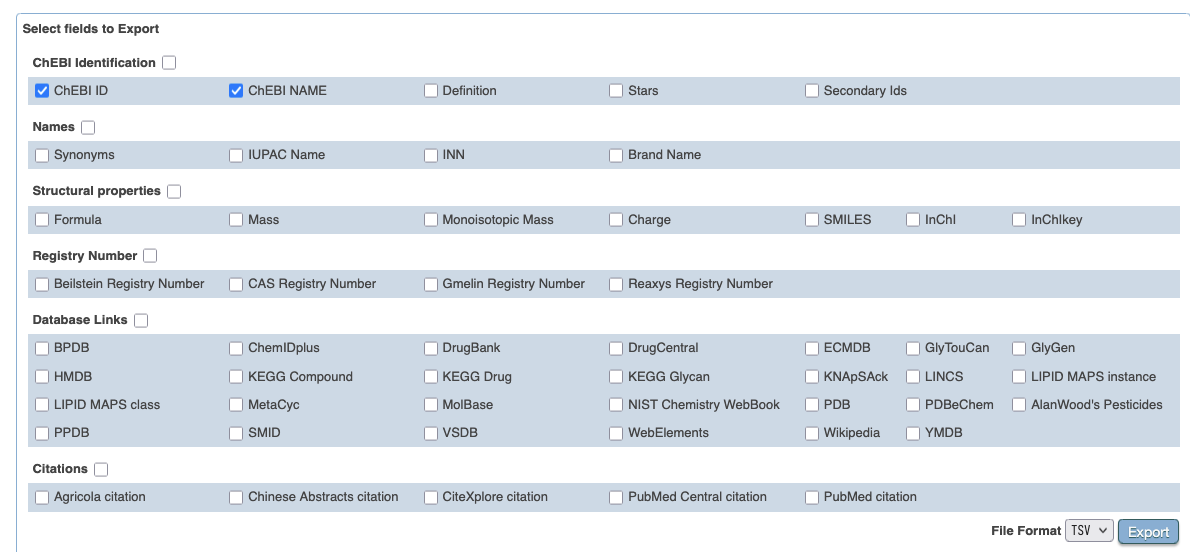





In [1]:
%pip install sdf

  Obtaining dependency information for sdf from https://files.pythonhosted.org/packages/aa/22/d7caebdec0d92bed8ca38cef79af36bfec859f6ab0f43368cfe1b3dc1214/SDF-0.3.6-py3-none-any.whl.metadata
  Obtaining dependency information for numpy>=2 from https://files.pythonhosted.org/packages/2b/3e/e7247c1d4f15086bb106c8d43c925b0b2ea20270224f5186fa48d4fb5cbd/numpy-2.2.4-cp311-cp311-macosx_14_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/61/d8/84da3fffefb6c7d5a16968fe5b9f24c98606b165bb801bb0b8bc3985200f/scipy-1.15.2-cp311-cp311-macosx_14_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.6/141.6 kB 4.3 MB/s eta 0:00:00

In [8]:
# read smiles
import pandas as pd

data = pd.read_csv('./ChEBI_results_2.tsv', sep='\t')
data['MASS'][:10]




CHEBI:23178     [H][C@@]1(CC[C@@]2([H])C3=CCC4CCCC[C@]4(C)[C@@...
CHEBI:28051     [H][C@@]12CC[C@H](C)CN1C[C@@]1([H])[C@]3(O)C[C...
CHEBI:28810     [H][C@@]1(CC[C@@]2([H])[C@]3([H])CC=C4CCCC[C@]...
CHEBI:35652     [H][C@@]12CC[C@H](C)CN1C[C@@]1([H])[C@]3(O)C[C...
CHEBI:37925     [H][C@@]12CCC3CCCC[C@]3(C)[C@@]1([H])CC[C@]1(C...
CHEBI:37927     [H][C@]12CCCC[C@]1(C)[C@@]1([H])CC[C@]3(C)C=CC...
CHEBI:52031     [H][C@@]12C[C@H](O)CC[C@]1(C)[C@@]1([H])CC[C@]...
CHEBI:61313               C1CCCC2C1(C3C(CC2)C4C(CC3)(C(CC4)CC)C)C
CHEBI:138029         C12C([C@]3(C(C(CC3)*)(C)CC1)C)CCC4C2(CCCC4)C
CHEBI:138031              C12C(C=3C(C(CC3)*)(C)CC1)CCC4C2(CCCC4)C
Name: MASS, dtype: object

In [9]:
import requests

def mkreq(smiles):
    # Define the SMILES string of the compound
    smiles = 'CCO'  # Example: Ethanol

    # Set the similarity cutoff (optional, default is 0.85)
    similarity_cutoff = 0.85

    # Construct the API URL
    url = f'https://bindingdb.org/axis2/services/BDBService/getTargetByCompound?smiles={smiles}&cutoff={similarity_cutoff}&response=application/json'

    # Send the GET request
    response = requests.get(url)

    # Check if the request was successful
    if response.status_code == 200:
        data = response.json()
        # Process the data as needed
        for item in data:
            print(f"Compound: {item.get('compoundName')}")
            print(f"Target: {item.get('targetName')}")
            print(f"Affinity: {item.get('affinityValue')} {item.get('affinityUnits')}")
            print('-' * 50)
    else:
        print(f"Error: {response.status_code}")

In [10]:
for sm in data['SMILES'][:10]:
  mkreq(sm)

Error: 404
Error: 404
Error: 404
Error: 404
Error: 404
Error: 404
Error: 404
Error: 404
Error: 404
Error: 404


In [2]:
import pandas as pd
bdata = pd.read_csv('./bindingdg/BindingDB_PubChem.tsv', sep='\t')
bdata

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

BindingDB seems promising, but shit doesn't work.
Fucking grant money ran out and server went kaput.
https://www.bindingdb.org/rwd/bind/chemsearch/marvin/Download.jsp
there's always downloads i guess, we can try to cook sth with that

# Post-debate shii

Ok bindingdb is my best friend.

For ligand we have a join between databases

Chebi_Results_2.tsv.id <-> bindingdb.'ChEBI ID of Ligand'

from that we can get 
- bindingdb.'... Target ... ' info, like its Id in other dbs
- Kd, Ki, IC50, EC50, (...what other shit to include?)


In [90]:
import pandas as pd
bdb_data = pd.read_csv('./data/bindingdb/BindingDB_PubChem.tsv',sep='\t')
chebi_data = pd.read_csv('./data/chebi/ChEBI_Results_2.tsv', index_col=False,  sep='\t')




/var/folders/92/3gzjc7p14mvb4pqkx2ryk0680000gn/T/ipykernel_55116/60412137.py:2: DtypeWarning: Columns (8,15,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  bdb_data = pd.read_csv('./data/bindingdb/BindingDB_PubChem.tsv',sep='\t')


In [91]:
chebi_data.rename(columns={'ID':'ChEBI ID of Ligand'}, inplace=True)
chebi_data

,ChEBI ID of Ligand,NAME,SECONDARY ID,FORMULA,MASS,SMILES,PDB ACCESSION
0,CHEBI:23178,cholest-7-ene,NaN,C27H46,370.65414,[H][C@@]1(CC[C@@]2([H])C3=CCC4CCCC[C@]4(C)[C@@...,NaN
1,CHEBI:28051,veratridine,CHEBI:27281; CHEBI:9952,C36H51NO11,673.79028,[H][C@@]12CC[C@H](C)CN1C[C@@]1([H])[C@]3(O)C[C...,NaN
2,CHEBI:28810,cholest-5-ene,CHEBI:2045; CHEBI:23174; CHEBI:23175,C27H46,370.65414,[H][C@@]1(CC[C@@]2([H])[C@]3([H])CC=C4CCCC[C@]...,NaN
3,CHEBI:35652,cevine,NaN,C27H43NO8,509.63220,[H][C@@]12CC[C@H](C)CN1C[C@@]1([H])[C@]3(O)C[C...,NaN
4,CHEBI:37925,androst-16-ene,NaN,C19H30,258.44150,[H][C@@]12CCC3CCCC[C@]3(C)[C@@]1([H])CC[C@]1(C...,NaN
...,...,...,...,...,...,...,...
5018,CHEBI:230917,"3a,7a,12a,19-Tetrahydroxy-5b-cholanoic acid",NaN,C24H40O6,424.57800,O[C@@H]1[C@]2([C@H]([C@H]3[C@@H]([C@@]4([C@H](...,NaN
5019,CHEBI:231062,Asi-222,NaN,C29H45NO7,519.67900,OC12C3C(C4(C(CC3)CC(OC5OC(C(N)C(O)C5O)C)CC4)C)...,NaN
5020,CHEBI:231164,7-Methyl-cholic acid,NaN,C25H42O5,422.60600,OC1(C2C3C(C(CC3)C(CCC(O)=O)C)(C(O)CC2C4(C(C1)C...,NaN
5021,CHEBI:231313,7.alpha.-Hydroxy-3-oxo-4-cholestenoic acid,NaN,C27H42O4,430.62900,O[C@H]1[C@H]2[C@H]3[C@@]([C@H](CC3)[C@@H](CCC[...,NaN


In [92]:


chebi_col_id = 'ChEBI ID of Ligand'
chebi_data = chebi_data.astype({chebi_col_id:'str'})
chebi_data[chebi_col_id] = chebi_data[chebi_col_id].str[6:]


In [93]:


bdb_data = bdb_data.dropna(subset=[chebi_col_id])
bdb_data[chebi_col_id] = bdb_data[chebi_col_id].astype(float).astype(int)
bdb_data = bdb_data.astype({chebi_col_id:'str'})



In [94]:
bdb_data[chebi_col_id]

243       28136
244        4821
246       64216
248       31490
249        2086
          ...  
120561    38565
120562    63632
120567     8452
120568     4659
120573     8711
Name: ChEBI ID of Ligand, Length: 2405, dtype: object

In [95]:

bdb_data.merge(chebi_data, on=chebi_col_id, how='inner')


,BindingDB Reactant_set_id,Ligand SMILES,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (TrEMBL) Entry Name of Target Chain,UniProt (TrEMBL) Primary ID of Target Chain,UniProt (TrEMBL) Secondary ID(s) of Target Chain,UniProt (TrEMBL) Alternative ID(s) of Target Chain,NAME,SECONDARY ID,FORMULA,MASS,SMILES,PDB ACCESSION
0,61496,C[C@]12CC[C@H]3[C@@H](CCc4c(O)c(O)ccc34)[C@@H]...,InChI=1S/C18H24O3/c1-18-9-8-11-10-4-6-15(19)17...,QOZFCKXEVSGWGS-ZHIYBZGJSA-N,34649,"(8R,9S,13S,14S,17S)-13-methyl-6,7,8,9,11,12,14...",Mannose-6-phosphate isomerase,Homo sapiens,NaN,29007,...,NaN,NaN,NaN,NaN,4-hydroxy-17beta-estradiol,CHEBI:34424,C18H24O3,288.38140,[H][C@]12CC[C@]3(C)[C@@H](O)CC[C@@]3([H])[C@]1...,NaN
1,73954,CCC(=O)O[C@@]1([C@@H](C)C[C@H]2[C@@H]3CCC4=CC(...,InChI=1S/C25H32ClFO5/c1-5-21(31)32-25(20(30)13...,CBGUOGMQLZIXBE-XGQKBEPLSA-N,39347,CLOBETASOL PROPIONATE::MLS000028708::SMR000058...,Genome polyprotein,West Nile virus,NaN,>50000,...,NaN,NaN,NaN,NaN,clobetasol propionate,CHEBI:205078; CHEBI:282070,C25H32ClFO5,466.97000,[H][C@@]12C[C@H](C)[C@](OC(=O)CC)(C(=O)CCl)[C@...,NaN
2,76044,C[C@]12CC[C@H]3[C@@H](C[C@H](O)c4cc(O)ccc34)[C...,InChI=1S/C18H24O3/c1-18-7-6-12-11-3-2-10(19)8-...,QZZRQURPSRWTLG-WOVZSMEKSA-N,40544,"(6S,8R,9S,13S,14S,17S)-13-methyl-6,7,8,9,11,12...",Estrogen receptor,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6alpha-hydroxy-17beta-estradiol,NaN,C18H24O3,288.38140,[H][C@]12CC[C@]3(C)[C@@H](O)CC[C@@]3([H])[C@]1...,NaN
3,77059,C[C@]12C[C@H](O)[C@@]3(F)[C@@H](CCC4=CC(=O)C=C...,InChI=1S/C21H27FO6/c1-18-6-5-12(24)7-11(18)3-4...,GFNANZIMVAIWHM-OBYCQNJPSA-N,41132,MLS000028542::SMR000058333::TRIAMCINOLONE::cid...,Procathepsin L,Homo sapiens,NaN,>50000,...,NaN,NaN,NaN,NaN,triamcinolone,NaN,C21H27FO6,394.43390,[H][C@@]12C[C@@H](O)[C@](O)(C(=O)CO)[C@@]1(C)C...,NaN
4,78463,C[C@]12CC[C@H]3[C@@H](C[C@H](O)c4cc(O)ccc34)[C...,InChI=1S/C18H24O3/c1-18-7-6-12-11-3-2-10(19)8-...,QZZRQURPSRWTLG-WOVZSMEKSA-N,40544,"(6S,8R,9S,13S,14S,17S)-13-methyl-6,7,8,9,11,12...",Estrogen receptor,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6alpha-hydroxy-17beta-estradiol,NaN,C18H24O3,288.38140,[H][C@]12CC[C@]3(C)[C@@H](O)CC[C@@]3([H])[C@]1...,NaN
5,82807,C[C@]12C[C@H](O)[C@@]3(F)[C@@H](CCC4=CC(=O)C=C...,InChI=1S/C21H27FO6/c1-18-6-5-12(24)7-11(18)3-4...,GFNANZIMVAIWHM-OBYCQNJPSA-N,41132,MLS000028542::SMR000058333::TRIAMCINOLONE::cid...,Multidrug resistance-associated protein 1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,triamcinolone,NaN,C21H27FO6,394.43390,[H][C@@]12C[C@@H](O)[C@](O)(C(=O)CO)[C@@]1(C)C...,NaN
6,86384,C[C@H]1O[C@H](C[C@H](O)[C@@H]1O)O[C@H]1[C@@H](...,InChI=1S/C41H64O14/c1-19-36(47)28(42)15-34(50-...,LTMHDMANZUZIPE-PUGKRICDSA-N,46355,DIGOXIN::MLS000069819::SMR000059217::US1066809...,Signal transducer and activator of transcripti...,Homo sapiens,NaN,1862,...,NaN,NaN,NaN,NaN,digoxin,CHEBI:41856; CHEBI:569365; CHEBI:616935,C41H64O14,780.93850,[H][C@]12CC[C@]3([H])[C@]([H])(C[C@@H](O)[C@]4...,1IGJ
7,86385,C[C@@H]1O[C@@H](O[C@H]2C[C@@H](O)[C@]3(CO)[C@H...,InChI=1S/C29H44O12/c1-13-22(34)23(35)24(36)25(...,LPMXVESGRSUGHW-HBYQJFLCSA-N,50286739,"4-((1R,3S,5S,8R,10R,11R,13R,14S,17R)-1,5,11,14...",Signal transducer and activator of transcripti...,Homo sapiens,NaN,1154,...,NaN,NaN,NaN,NaN,ouabain,CHEBI:44461; CHEBI:7805,C29H44O12,584.65250,[H][C@@]12CC[C@]3(O)C[C@H](C[C@@H](O)[C@]3(CO)...,NaN
8,86386,C[C@H]1O[C@H](C[C@H](O)[C@@H]1O)O[C@H]1[C@@H](...,InChI=1S/C41H64O13/c1-20-36(46)29(42)16-34(49-...,WDJUZGPOPHTGOT-XUDUSOBPSA-N,46356,DIGITOXIN::MLS000069787::SMR000058529::US10668...,Signal transducer and activator of transcripti...,Homo sapiens,NaN,700,...,NaN,NaN,NaN,NaN,digitoxin,CHEBI:4549; CHEBI:23728,C41H64O13,764.93910,[H][C@]12CC[C@]3([H])[C@]([H])(CC[C@]4(C)[C@](...,NaN
9,86555,C[C@H]1O[C@H](C[C@H](O)[C@@H]1O)O[C@H]1[C@@H](...,InChI=1S/C41H64O14/c1-19-36(47)28(42)15-34(50-...,LTMHDMANZUZIPE-PUGKRICDSA-N,46355,DIGOXIN::MLS000069819::SMR000059217::US1066809...,S

Well that's not great. 34 rows for the small dataset kinda sucks. 
TODO: check in real, big file